In [ ]:
# Import Library
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [ ]:
 # Load dataset
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


EDA

In [ ]:
# Cek dataset
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
# Cek data duplikat
duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 3854


In [ ]:
df = df.drop_duplicates()

print("Ukuran dataset setelah menghapus duplikat:")
print(df.shape)

Ukuran dataset setelah menghapus duplikat:
(96146, 9)


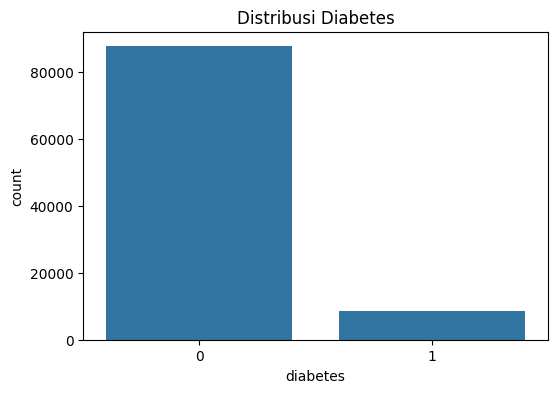

In [ ]:
# Distribusi diabetes
plt.figure(figsize=(6,4))

sns.countplot(x='diabetes', data=df)

plt.title('Distribusi Diabetes')

plt.show()

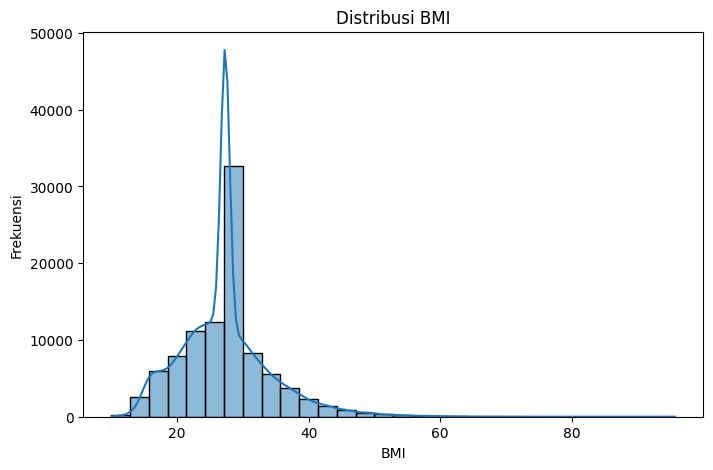

In [ ]:
# Distribusi BMI

plt.figure(figsize=(8,5))

sns.histplot(
    df['bmi'],
    bins=30,
    kde=True
)

plt.title("Distribusi BMI")

plt.xlabel("BMI")

plt.ylabel("Frekuensi")

plt.show()

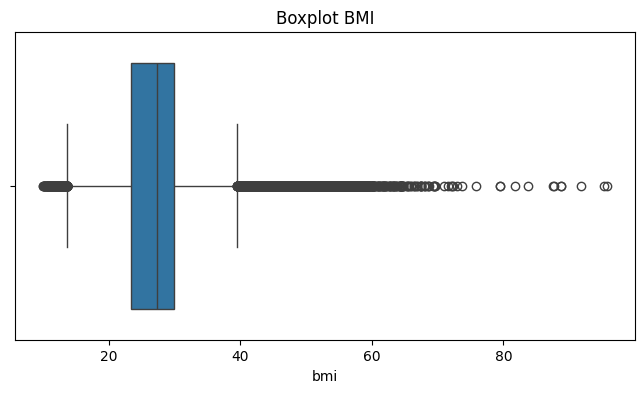

In [ ]:
# Deteksi Outlier BMI

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['bmi']
)

plt.title("Boxplot BMI")

plt.show()

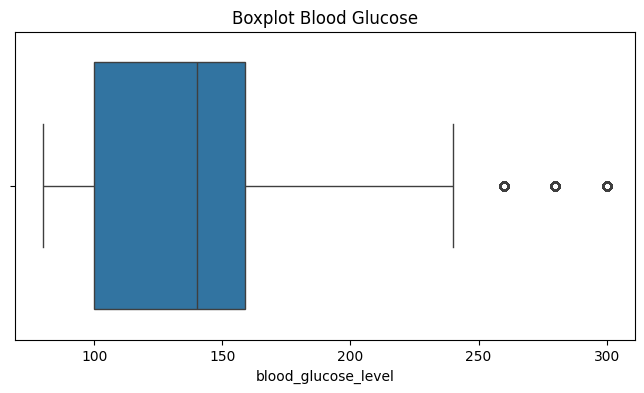

In [ ]:
# Deteksi Outlier Blood Glucose

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['blood_glucose_level']
)

plt.title("Boxplot Blood Glucose")

plt.show()

In [ ]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

df['smoking_history'] = le.fit_transform(df['smoking_history'])

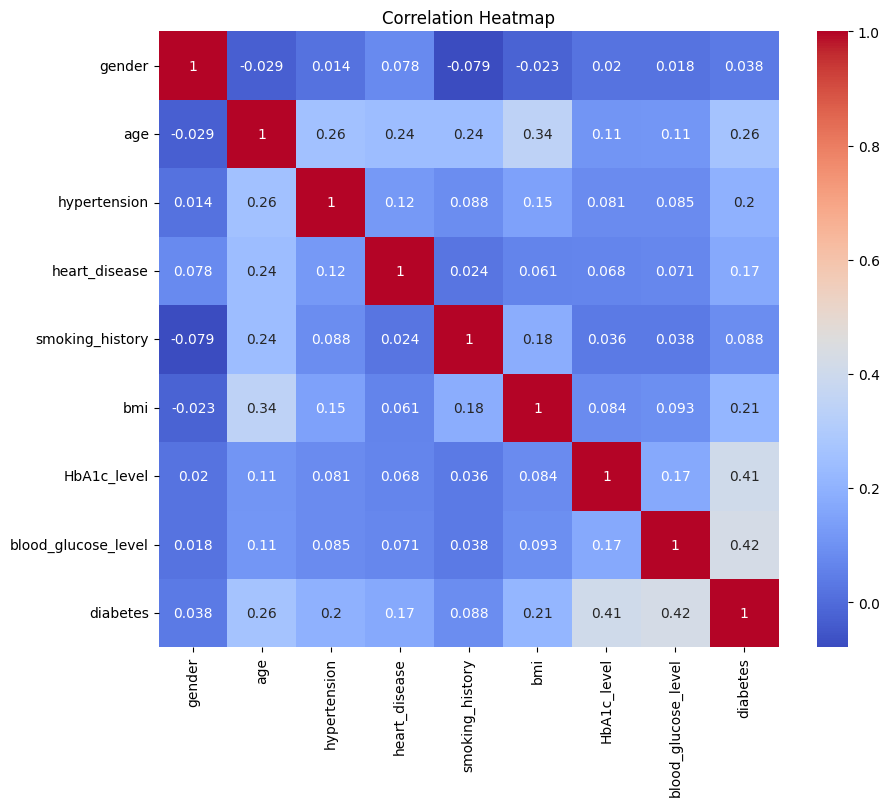

In [ ]:
# Korelasi antar fitur

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# confusion matrix model terbaik
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.965107,0.855656,0.727005,0.786101,0.857571
2,Random Forest,0.956526,0.758413,0.744104,0.751190,0.860588
1,Decision Tree,0.946178,0.676079,0.748231,0.710327,0.856778
3,KNN,0.896048,0.450635,0.815448,0.580483,0.859646
0,Logistic Regression,0.879615,0.412397,0.859080,0.557277,0.870341


In [ ]:
# Ambil model terbaik

best_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

best_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_best = best_model.predict(X_test)

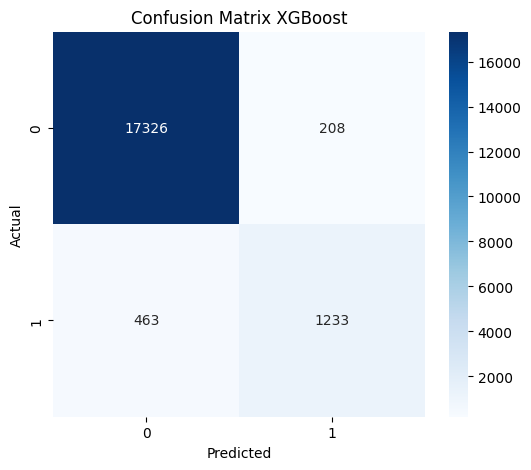

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix XGBoost")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

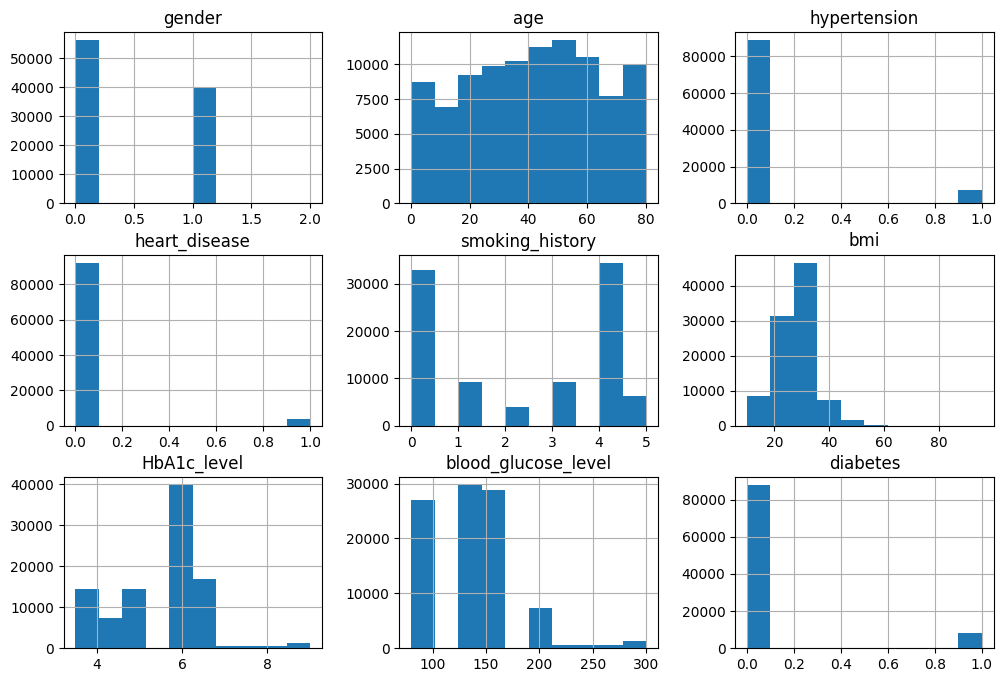

In [ ]:
# distribusi numerik
df.hist(figsize=(12,8))
plt.show()

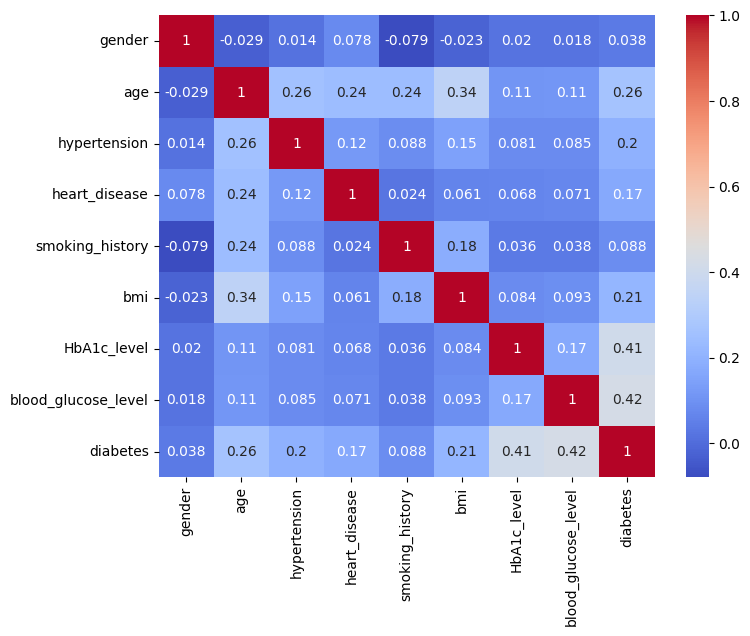

In [ ]:
# Korelasi
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

<Axes: xlabel='age', ylabel='Count'>

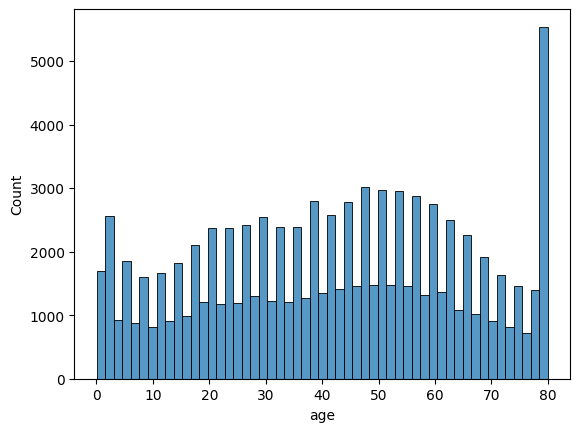

In [ ]:
# distribusi umur
sns.histplot(df['age'])

In [ ]:
# duplikasi data
print(df.duplicated().sum())

0


In [ ]:
df.drop_duplicates(inplace=True)

<Axes: ylabel='bmi'>

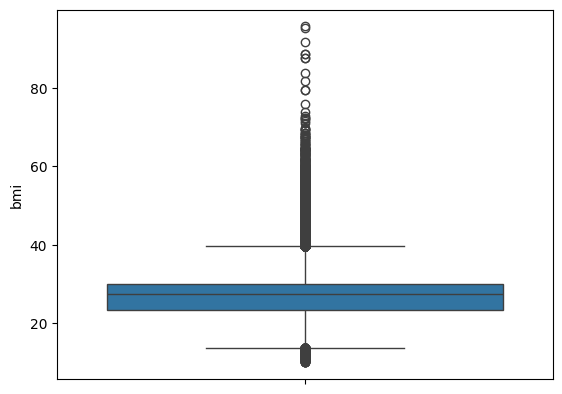

In [ ]:
# Outlier
sns.boxplot(df['bmi'])

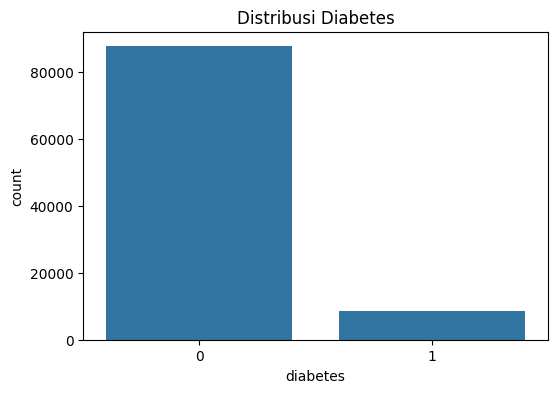

In [ ]:
# Distribusi target
plt.figure(figsize=(6,4))

sns.countplot(x='diabetes', data=df)

plt.title('Distribusi Diabetes')
plt.show()

In [ ]:
# Encoding data kategorikal
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])

In [ ]:
# memisahkan fitur dan target
X = df.drop('diabetes', axis=1)

y = df['diabetes']

In [ ]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# SMOTE = karena data nya tidak seimbang
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())

print(y_train_smote.value_counts())

diabetes
0    70130
1     6786
Name: count, dtype: int64
diabetes
0    70130
1    70130
Name: count, dtype: int64


In [ ]:
# Scaling
scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)

X_test = scaler.transform(X_test)

In [ ]:
# membuat model
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "XGBoost":
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        )
}

In [ ]:
# Training dan evaluasi
results = []

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("="*50)
    print(name)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.88      0.93     17534
           1       0.41      0.86      0.56      1696

    accuracy                           0.88     19230
   macro avg       0.70      0.87      0.74     19230
weighted avg       0.93      0.88      0.90     19230

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     17534
           1       0.68      0.75      0.71      1696

    accuracy                           0.95     19230
   macro avg       0.83      0.86      0.84     19230
weighted avg       0.95      0.95      0.95     19230

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17534
           1       0.76      0.74      0.75      1696

    accuracy                           0.96     19230
   macro avg       0.87      0.86      0.86     19230
weighted avg       0.96   

In [ ]:
# Tabel hasil
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.879615,0.412397,0.859080,0.557277,0.870341
1,Decision Tree,0.946178,0.676079,0.748231,0.710327,0.856778
2,Random Forest,0.956526,0.758413,0.744104,0.751190,0.860588
3,KNN,0.896048,0.450635,0.815448,0.580483,0.859646
4,XGBoost,0.965107,0.855656,0.727005,0.786101,0.857571


## Analisis Model Terbaik

Berdasarkan hasil evaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan ROC-AUC, model dengan performa terbaik adalah XGBoost.

XGBoost mampu menghasilkan nilai evaluasi yang lebih tinggi dibandingkan model lainnya karena menggunakan metode boosting yang membangun model secara bertahap dan memperbaiki kesalahan prediksi sebelumnya.

Hal ini menunjukkan bahwa hubungan antar fitur kesehatan seperti usia, BMI, HbA1c level, dan blood glucose level memiliki pola yang cukup kompleks sehingga lebih baik ditangkap oleh algoritma boosting dibandingkan model linear maupun model berbasis jarak.

In [ ]:
#Urutkan model terbaik
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.965107,0.855656,0.727005,0.786101,0.857571
2,Random Forest,0.956526,0.758413,0.744104,0.751190,0.860588
1,Decision Tree,0.946178,0.676079,0.748231,0.710327,0.856778
3,KNN,0.896048,0.450635,0.815448,0.580483,0.859646
0,Logistic Regression,0.879615,0.412397,0.859080,0.557277,0.870341


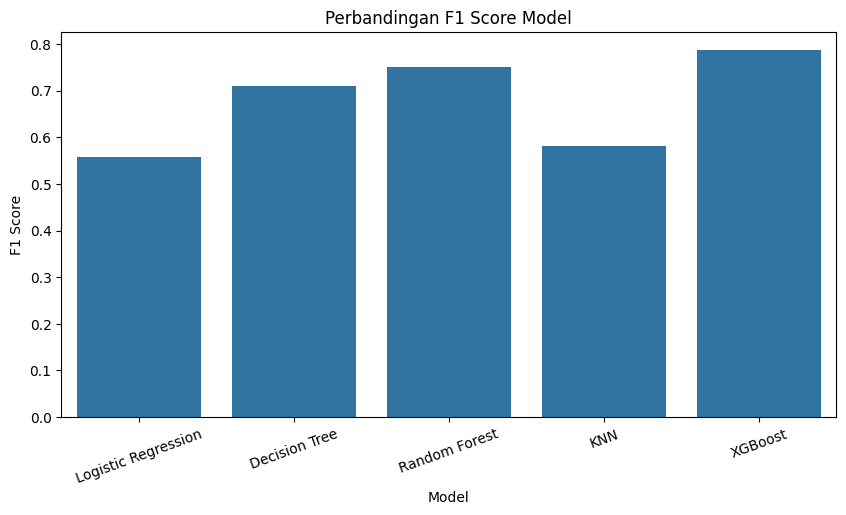

In [ ]:
# visualisasi perbandingan model
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.title("Perbandingan F1 Score Model")

plt.xticks(rotation=20)

plt.show()

In [ ]:
# feature importance Random forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
6,HbA1c_level,0.399506
7,blood_glucose_level,0.253104
1,age,0.199335
5,bmi,0.107539
4,smoking_history,0.027758
0,gender,0.007278
2,hypertension,0.003318
3,heart_disease,0.002161


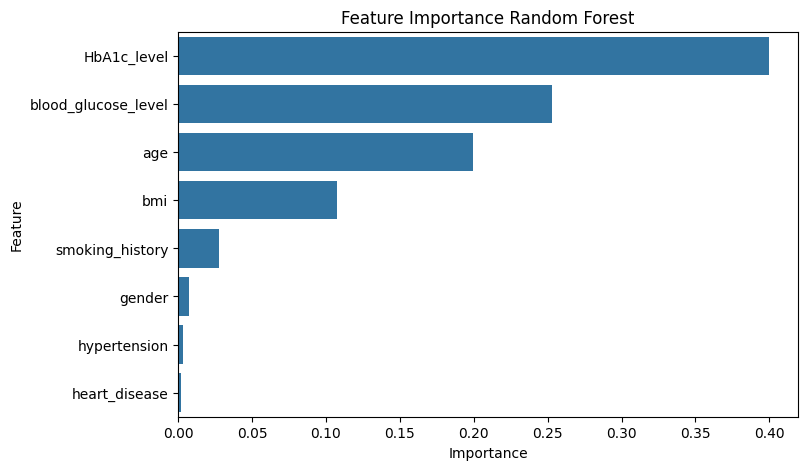

In [ ]:
# visualisasi
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance Random Forest')

plt.show()

## Analisis Feature Importance

Berdasarkan hasil feature importance dari Random Forest, fitur yang memiliki pengaruh terbesar terhadap prediksi diabetes adalah HbA1c Level dan Blood Glucose Level.

Hasil ini sesuai dengan kondisi medis karena kedua indikator tersebut merupakan parameter utama yang digunakan dalam diagnosis diabetes. Selain itu, usia dan BMI juga memberikan kontribusi yang cukup besar terhadap proses prediksi.

# Kesimpulan

Penelitian ini berhasil membangun model Machine Learning untuk memprediksi risiko diabetes berdasarkan data kesehatan pasien.

Lima algoritma Machine Learning dibandingkan yaitu Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbor (KNN), dan XGBoost.

Berdasarkan hasil evaluasi, model XGBoost memberikan performa terbaik dengan nilai Accuracy, Precision, Recall, F1-Score, dan ROC-AUC tertinggi dibandingkan model lainnya.

Fitur yang paling berpengaruh terhadap prediksi diabetes adalah HbA1c Level, Blood Glucose Level, Age, dan BMI.

Dengan demikian, model XGBoost dapat digunakan sebagai model yang efektif untuk membantu prediksi risiko diabetes secara lebih dini.
